# Fase 2 — Análisis Exploratorio de Datos (EDA)
**Grupo 3 · Evento Evaluativo 2 · Análisis de Datos**
Dataset seleccionado: **Titanic** (ver justificación en `01_exploracion_datasets.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('whitegrid')

titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2.1 Revisión de valores faltantes

In [2]:
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
missing_table = pd.DataFrame({'faltantes': missing, 'porcentaje': missing_pct})
missing_table = missing_table[missing_table['faltantes'] > 0].sort_values('porcentaje', ascending=False)
missing_table

,faltantes,porcentaje
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


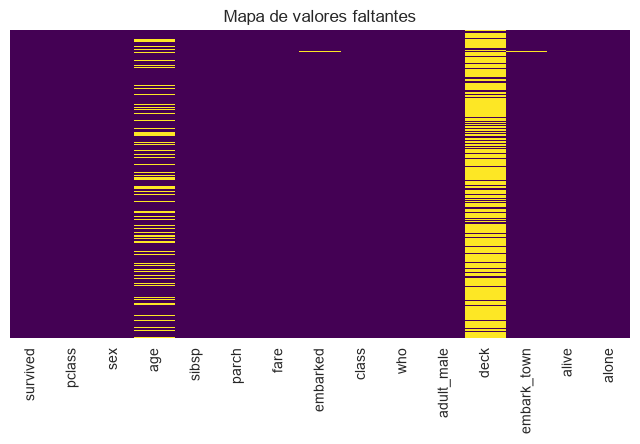

In [3]:
plt.figure(figsize=(8, 4))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

**Interpretación y estrategia de tratamiento:**
- `deck` falta en ~77% de los registros: es demasiado para imputar de forma confiable. Estrategia: **eliminar la columna** (o, alternativamente, crear un indicador binario `tiene_deck_registrado`).
- `age` falta en ~20% de los registros: suficiente información para imputar. Estrategia: **imputar con la mediana** (más robusta que la media frente a los valores atípicos que veremos en 2.2), y opcionalmente crear un indicador `age_imputada` para no perder la señal de que el dato era desconocido.
- `embarked`/`embark_town` falta en solo 2 registros (~0.2%): Estrategia: **imputar con la moda** (el puerto más frecuente) o eliminar esas 2 filas sin impacto relevante.

## 2.2 Detección de valores atípicos

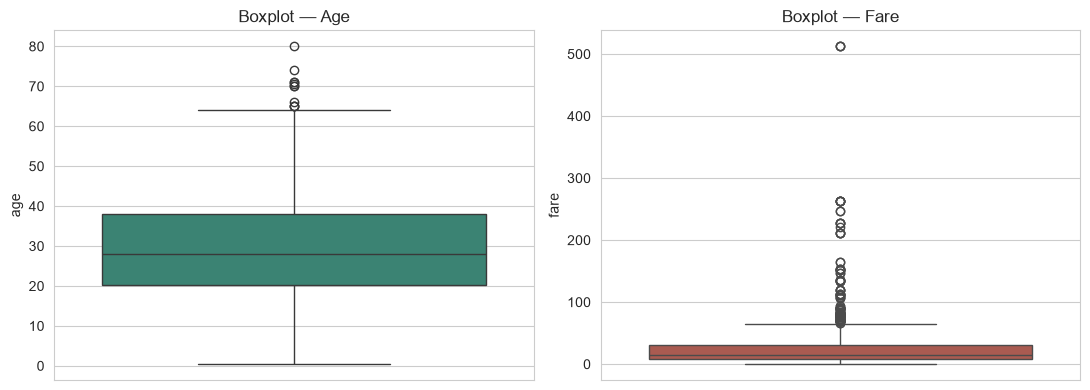

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=titanic['age'], ax=axes[0], color='#2F8F7A')
axes[0].set_title('Boxplot — Age')
sns.boxplot(y=titanic['fare'], ax=axes[1], color='#B85042')
axes[1].set_title('Boxplot — Fare')
plt.tight_layout()
plt.show()

In [5]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series[(series < lower) | (series > upper)], lower, upper

for col in ['age', 'fare']:
    out, low, high = iqr_outliers(titanic[col].dropna())
    z = np.abs(stats.zscore(titanic[col].dropna()))
    print(f"--- {col} ---")
    print(f"Rango IQR normal: [{low:.1f}, {high:.1f}]  ->  {len(out)} valores atípicos ({len(out)/titanic[col].notna().sum()*100:.1f}%)")
    print(f"Valores con |z-score| > 3: {(z > 3).sum()}")
    print()

--- age ---
Rango IQR normal: [-6.7, 64.8]  ->  11 valores atípicos (1.5%)
Valores con |z-score| > 3: 2

--- fare ---
Rango IQR normal: [-26.7, 65.6]  ->  116 valores atípicos (13.0%)
Valores con |z-score| > 3: 20



**Discusión:** `fare` tiene una cola larga de valores altos (pasajes de primera clase muy costosos) — son atípicos estadísticamente, pero representan pasajeros reales de alto poder adquisitivo, no errores de captura, así que **se conservan** (podrían transformarse con logaritmo más adelante si afectan un modelo). `age` tiene pocos atípicos (personas muy mayores), también plausibles y se conservan.

## 2.3 Análisis de distribuciones

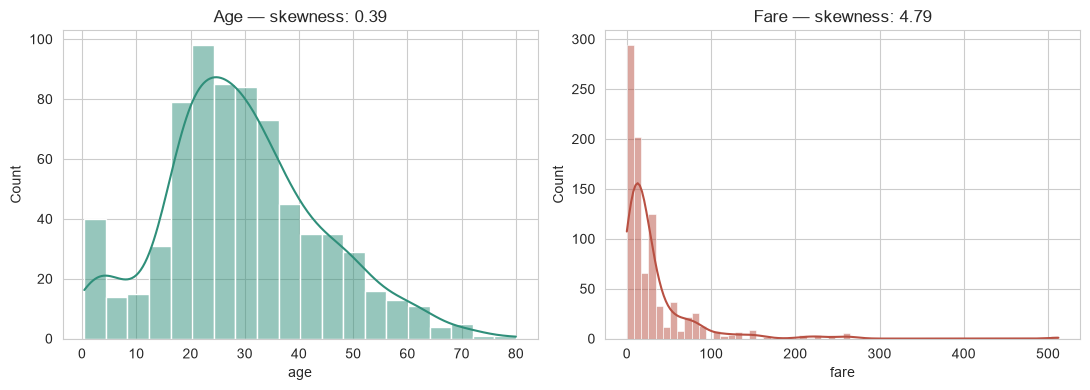

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(titanic['age'].dropna(), kde=True, ax=axes[0], color='#2F8F7A')
axes[0].set_title(f"Age — skewness: {titanic['age'].skew():.2f}")
sns.histplot(titanic['fare'], kde=True, ax=axes[1], color='#B85042')
axes[1].set_title(f"Fare — skewness: {titanic['fare'].skew():.2f}")
plt.tight_layout()
plt.show()

**Interpretación:** `age` tiene una distribución aproximadamente simétrica (sesgo cercano a 0), cercana a una normal. `fare` tiene un sesgo positivo fuerte (cola larga a la derecha) — es candidata a una **transformación logarítmica** antes de usarla en modelos sensibles a la escala o a la normalidad.

## 2.4 Análisis univariado

In [7]:
titanic[['age', 'fare', 'sibsp', 'parch']].describe()

,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


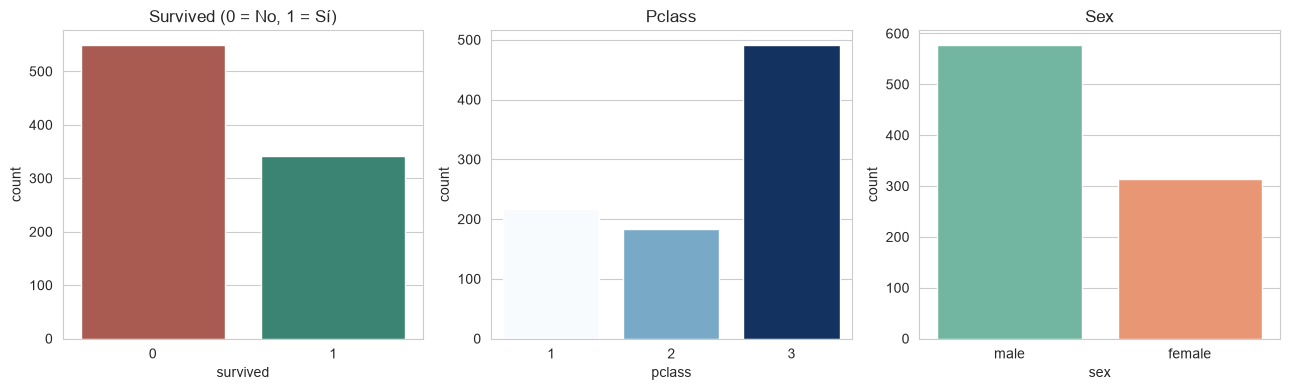

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.countplot(x='survived', data=titanic, ax=axes[0], hue='survived', palette=['#B85042', '#2F8F7A'], legend=False)
axes[0].set_title('Survived (0 = No, 1 = Sí)')
sns.countplot(x='pclass', data=titanic, ax=axes[1], hue='pclass', palette='Blues', legend=False)
axes[1].set_title('Pclass')
sns.countplot(x='sex', data=titanic, ax=axes[2], hue='sex', palette='Set2', legend=False)
axes[2].set_title('Sex')
plt.tight_layout()
plt.show()

**Interpretación:** sobrevivió solo el ~38% de los pasajeros. La mayoría viajaba en 3ª clase, y hay más hombres que mujeres a bordo — ambos factores resultarán relevantes en el análisis multivariado.

## 2.5 Análisis multivariado y relaciones entre variables

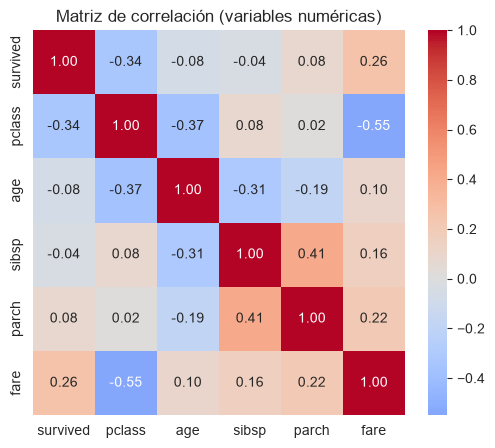

In [9]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = titanic[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

In [10]:
pd.crosstab(titanic['sex'], titanic['survived'], normalize='index').round(3) * 100

survived,0,1
sex,,
female,25.8,74.2
male,81.1,18.9


In [11]:
pd.crosstab(titanic['pclass'], titanic['survived'], normalize='index').round(3) * 100

survived,0,1
pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


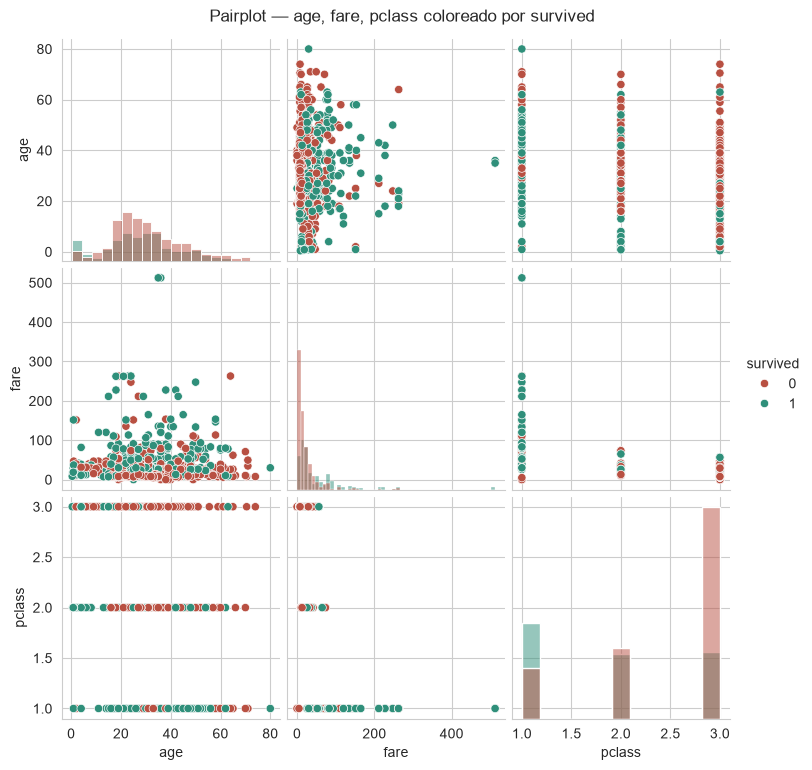

In [12]:
sns.pairplot(titanic[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived', palette=['#B85042', '#2F8F7A'], diag_kind='hist')
plt.suptitle('Pairplot — age, fare, pclass coloreado por survived', y=1.02)
plt.show()

**Interpretación:** `fare` y `pclass` tienen una correlación negativa fuerte (esperado: mejor clase = pasaje más caro = número de clase más bajo). `survived` correlaciona positivamente con `fare` y negativamente con `pclass`: viajar en una clase mejor y pagar más estuvo asociado con mayor probabilidad de supervivencia. Las tablas cruzadas muestran que el ~74% de las mujeres sobrevivió frente a solo ~19% de los hombres, y que la supervivencia en 1ª clase (~63%) casi triplica la de 3ª clase (~24%).

## 2.6 Construcción de hipótesis iniciales

A partir de los patrones anteriores, planteamos dos hipótesis para verificar formalmente en la sección 2.7 (nivel de significancia α = 0.05):

1. **H1 — Sexo y supervivencia:**
   - H0: el sexo y la supervivencia son independientes.
   - H1: existe una relación entre el sexo del pasajero y la probabilidad de sobrevivir (se sospecha que las mujeres sobrevivieron más, posiblemente por el protocolo "mujeres y niños primero").
2. **H2 — Edad y supervivencia:**
   - H0: la edad promedio de sobrevivientes y no sobrevivientes es igual.
   - H1: la edad promedio difiere entre ambos grupos (se sospecha que los pasajeros más jóvenes tuvieron mayor probabilidad de sobrevivir).

## 2.7 Pruebas de hipótesis (inferencia estadística — Semana 6)

In [13]:
# H1: chi-cuadrado entre sexo y supervivencia
contingencia = pd.crosstab(titanic['sex'], titanic['survived'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingencia)
print('Tabla de contingencia:')
print(contingencia)
print(f"\nEstadístico chi-cuadrado: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_chi2:.6f}")
alpha = 0.05
if p_chi2 < alpha:
    print(f"Como p < {alpha}, se RECHAZA H0: hay evidencia de relación entre sexo y supervivencia.")
else:
    print(f"Como p >= {alpha}, NO se rechaza H0.")

Tabla de contingencia:
survived    0    1
sex               
female     81  233
male      468  109

Estadístico chi-cuadrado: 260.72
Grados de libertad: 1
Valor p: 0.000000
Como p < 0.05, se RECHAZA H0: hay evidencia de relación entre sexo y supervivencia.


In [14]:
# H2: prueba t entre edad de sobrevivientes y no sobrevivientes
edad_sobrevivientes = titanic.loc[titanic['survived'] == 1, 'age'].dropna()
edad_no_sobrevivientes = titanic.loc[titanic['survived'] == 0, 'age'].dropna()

t_stat, p_t = stats.ttest_ind(edad_sobrevivientes, edad_no_sobrevivientes, equal_var=False)
print(f"Edad media sobrevivientes: {edad_sobrevivientes.mean():.1f} años (n={len(edad_sobrevivientes)})")
print(f"Edad media no sobrevivientes: {edad_no_sobrevivientes.mean():.1f} años (n={len(edad_no_sobrevivientes)})")
print(f"\nEstadístico t: {t_stat:.2f}")
print(f"Valor p: {p_t:.4f}")
if p_t < alpha:
    print(f"Como p < {alpha}, se RECHAZA H0: la diferencia de edad entre grupos es estadísticamente significativa.")
else:
    print(f"Como p >= {alpha}, NO se rechaza H0: no hay evidencia suficiente de diferencia de edad entre grupos.")

Edad media sobrevivientes: 28.3 años (n=290)
Edad media no sobrevivientes: 30.6 años (n=424)

Estadístico t: -2.05
Valor p: 0.0412
Como p < 0.05, se RECHAZA H0: la diferencia de edad entre grupos es estadísticamente significativa.


**Conclusión de las pruebas:**
- **H1:** el estadístico chi-cuadrado (260.72, 1 g.l.) da un valor p prácticamente 0, así que se rechaza H0: el sexo está fuertemente asociado con la supervivencia.
- **H2:** la edad media de los sobrevivientes (28.3 años) es algo menor que la de los no sobrevivientes (30.6 años); con t = −2.05 y p = 0.041 < 0.05 se rechaza H0, pero el resultado está cerca del umbral y la diferencia (~2 años) es pequeña frente al efecto del sexo.
- En conjunto, el sexo (y la clase) explican mucho más la supervivencia que la edad por sí sola.

## 2.8 Insights principales

1. Solo sobrevivió el ~38% de los pasajeros: la muestra está desbalanceada hacia "no sobrevivió".
2. El sexo es el factor individual más fuertemente asociado con la supervivencia (confirmado con chi-cuadrado, p ≈ 0): las mujeres sobrevivieron en una proporción mucho mayor que los hombres.
3. La clase del pasaje (`pclass`) y la tarifa (`fare`) están fuertemente correlacionadas entre sí (≈ −0.55) y moderadamente con la supervivencia (≈ −0.34 y ≈ 0.26): viajar en mejor clase se asoció con mayor probabilidad de sobrevivir.
4. `deck` tiene ~77% de datos faltantes y debe tratarse con cuidado (eliminar o convertir en indicador), mientras que `age` (~20% faltante) sí es recuperable mediante imputación.
5. `fare` presenta un sesgo positivo fuerte y varios valores atípicos altos (pasajes de primera clase muy costosos) que conviene transformar logarítmicamente antes de un modelado posterior.
6. La diferencia de edad entre sobrevivientes y no sobrevivientes es más débil que el efecto del sexo o la clase, lo que sugiere que estas dos últimas variables son mejores candidatas como predictoras principales en una futura fase de modelado.